# Module 1 Topic 2 Practice - Regression

## Exercise 1: Understand data
Download the data

In [42]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Load the dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

Explore the data, please execute the code below and play with the data.

Dataset Overview:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Pop

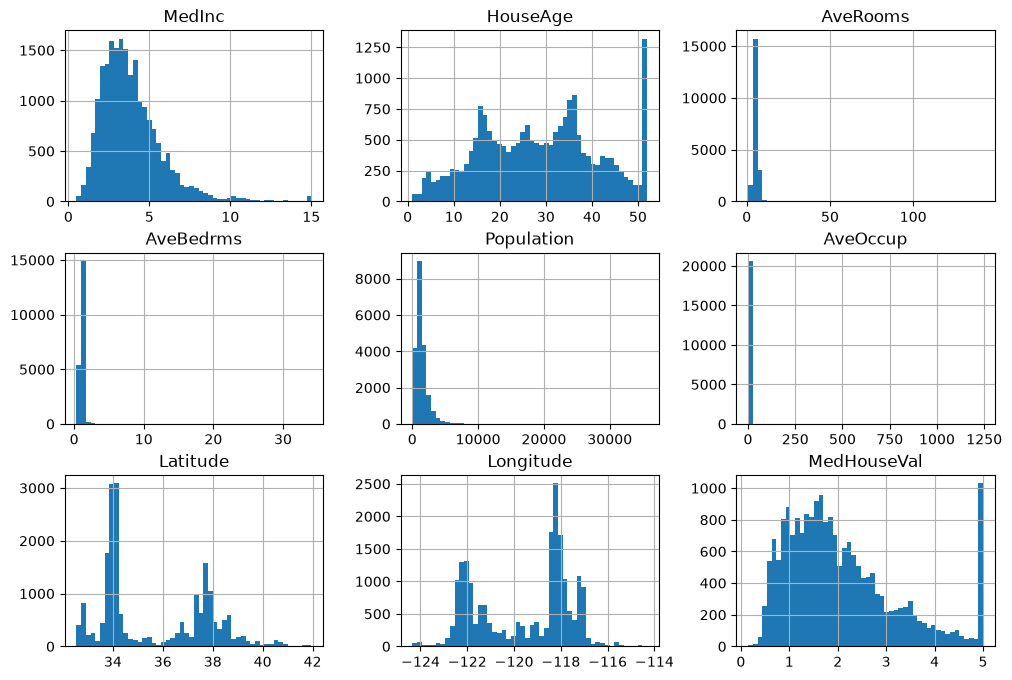

In [43]:

# Display the first few rows
print("Dataset Overview:")
print(df.head())
print(df.info())

df.hist(bins=50, figsize=(12, 8))
plt.show()

## Question 1 (30 pts）
- Can you figure out what these headers mean?
- From these graph, what would be the features that could predict the house value?

Enter your answers in the following cell

1. These headers represent the Median Income of the household, median age, average number of rooms, average number of bedrooms, population of the census district, Average number of occupants, latitude, longitude, and the Median House Value of the houses in California.

2. From these graph, Median Income seems to be the feature that could predict the house value most accurately since the features of their graphs are identical. Probably because richer people can afford more expensive houses.

## Exercise 2: Train a linear regression model

Mean Squared Error: 0.53
R-squared: 0.60


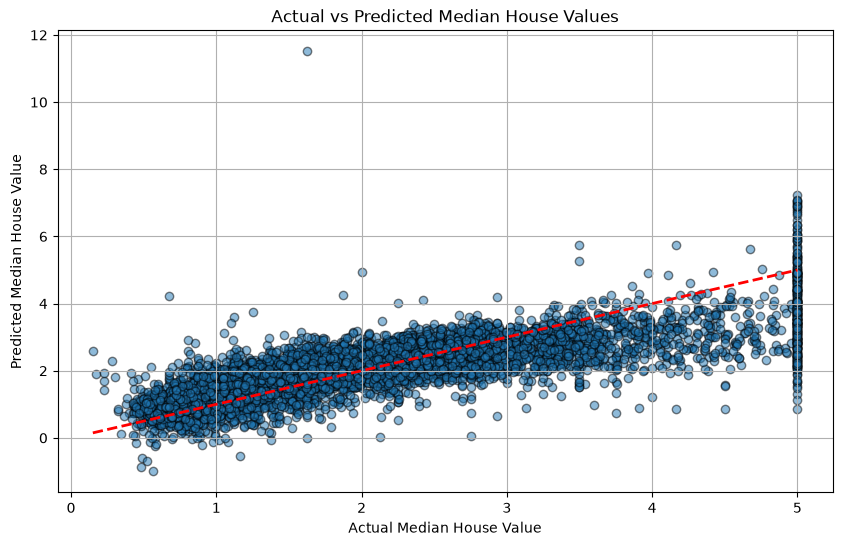


Feature Importance:
      Feature   Coefficient
3   AveBedrms  7.785996e-01
0      MedInc  4.458226e-01
1    HouseAge  9.681868e-03
4  Population -7.757404e-07
5    AveOccup -3.370027e-03
2    AveRooms -1.220951e-01
6    Latitude -4.185367e-01
7   Longitude -4.336880e-01


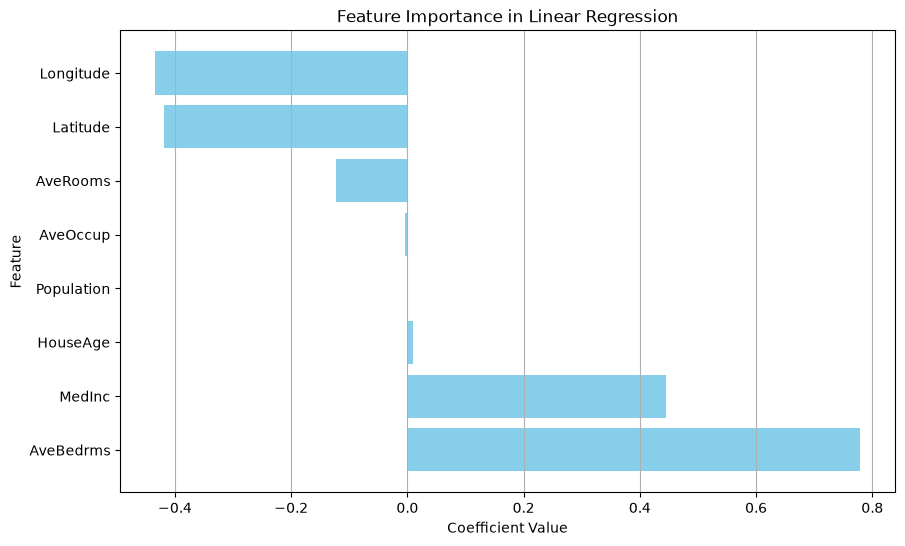

In [44]:

# Features and target
X = df.drop(columns=["MedHouseVal"])  # Features
y = df["MedHouseVal"]  # Target (Median House Value)


# Step 2: Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Step 3: Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = model.predict(X_test)

# Step 5: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Step 6: Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Median House Values")
plt.grid()
plt.show()

# Step 7: Feature importance (coefficients)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance:")
print(coefficients)

# Step 8: Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"], color='skyblue')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance in Linear Regression")
plt.grid(axis='x')
plt.show()

## Question 2 (30 pts)
- What did you see?
- What are the important features?

1. Looks like the linear regression model can predict the Median house value quite accurately, although as the more valuable the houses get, the more unreliable the model becomes.

2. Average bedrooms in a house and the median income of the household in the house seems to be the most important features and have a positive correlation with median house value. On the other hand, latitude and longitude has a negative correlation with the house value. All of these can be used to accurately predict median house value.

## Exercise 3: feature engineering

Below is an example where we chose longitude and latitude as the features to predict median house value. Note that the visualization highlights the geographical distribution of house values, which provides insights into how location influences housing prices. While the model may capture spatial trends, the prediction accuracy might be limited since other factors like income or population density are not included.

Mean Squared Error: 0.99
R-squared: 0.25


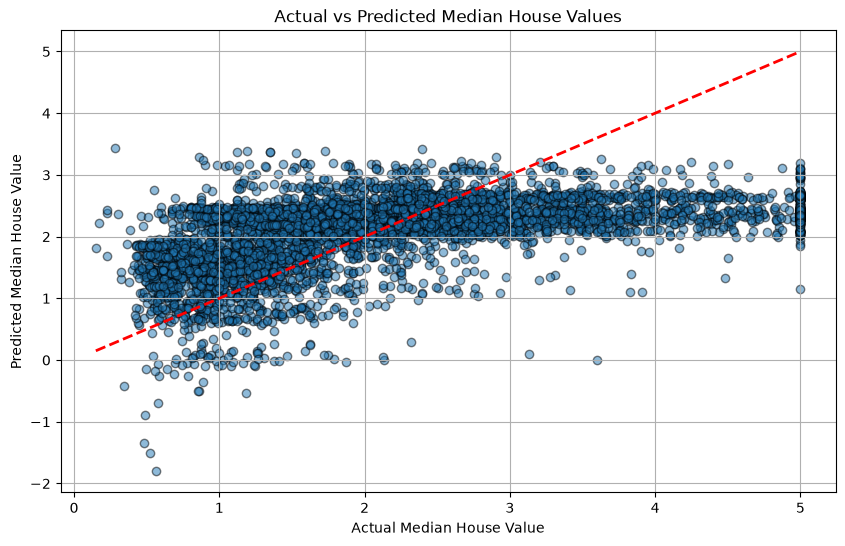

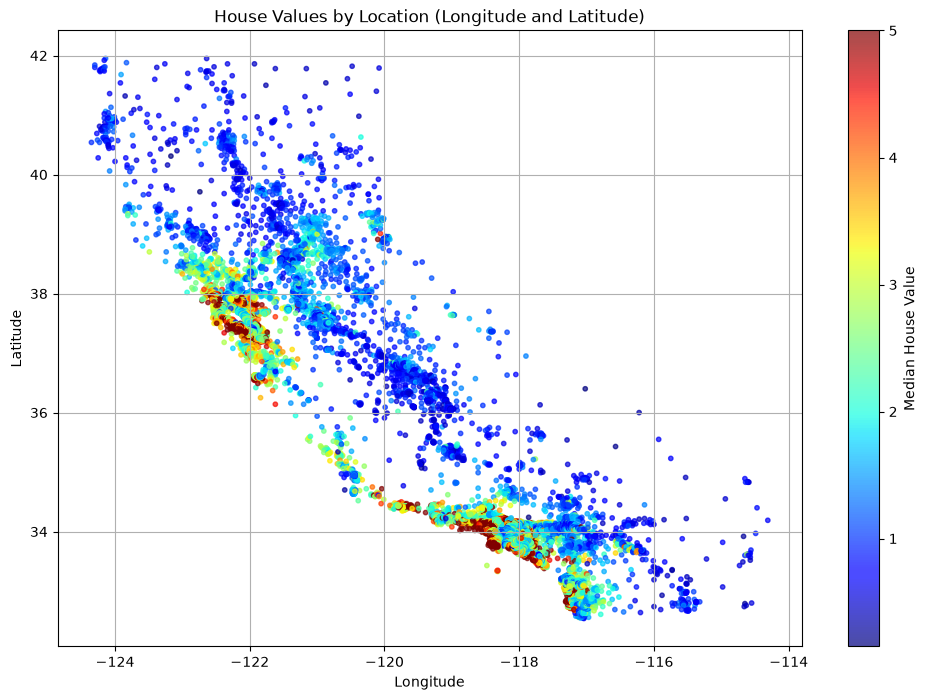

In [45]:
# Use only longitude and latitude as features
X = df[["Longitude", "Latitude"]]
y = df["MedHouseVal"]  # Target (Median House Value)

# Step 2: Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = model.predict(X_test)

# Step 5: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Step 6: Visualize predictions on a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Median House Values")
plt.grid()
plt.show()

# Step 7: Visualize Longitude, Latitude, and House Value
plt.figure(figsize=(12, 8))
plt.scatter(X["Longitude"], X["Latitude"], c=y, cmap="jet", s=10, alpha=0.7)
plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Values by Location (Longitude and Latitude)")
plt.grid()
plt.show()

It’s your turn now! Copy the cell above, modify the code and pick different features. Compare the results you obtain, and visualize the features in interesting ways. Explain your findings and discuss the results.

Mean Squared Error: 0.54
R-squared: 0.59


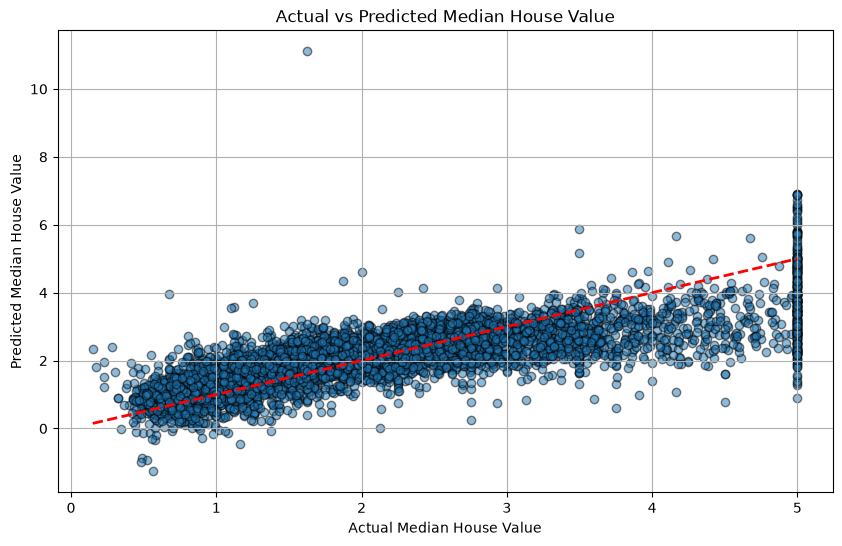

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [46]:

# Features and target 
##########################################
# PRACTICE: pick different features here #
##########################################
X = df[["AveBedrms", "MedInc", "Longitude", "Latitude", "AveRooms"]]  # Features
y = df["MedHouseVal"]  # Target (Median House Value)


# Step 2: Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Step 3: Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = model.predict(X_test)

# Step 5: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Step 6: Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Median House Value")
plt.grid()
plt.show()

print(df.head())



## Question 3.1

Try creating the plots below

- Visualize the relationship between features and house value
- Scatter plot for Median Income vs House Value
- Scatter plot for AveBedrms vs House Value
- Create one visualisation that is different from all the above

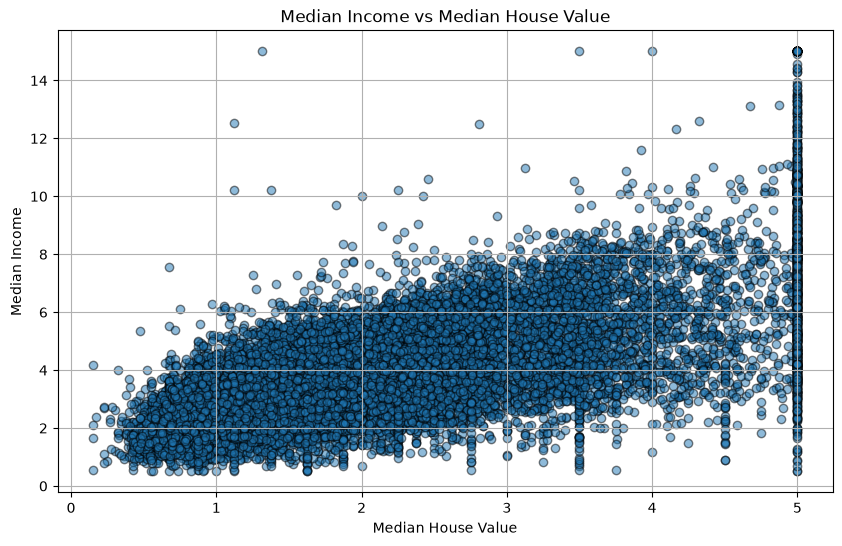

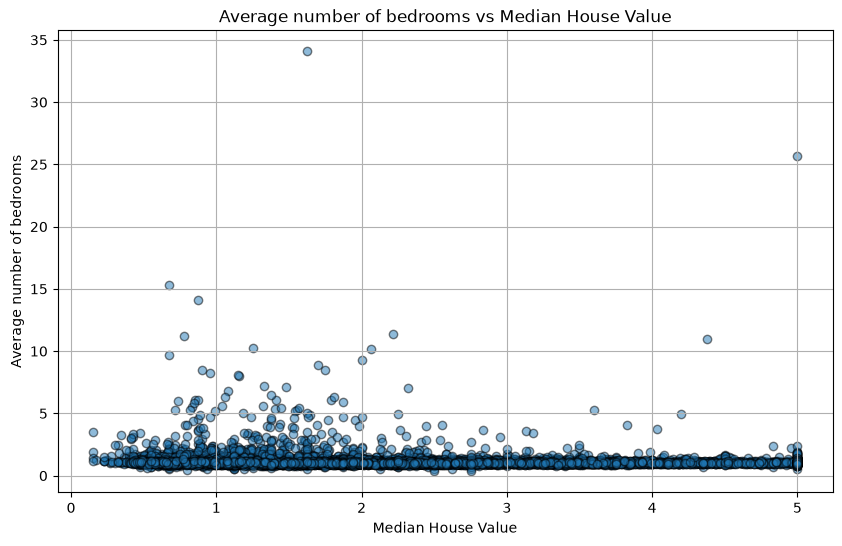

In [47]:
# Median Income vs Median House Value scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df['MedHouseVal'], df['MedInc'], alpha=0.5, edgecolor='k')
plt.xlabel("Median House Value")
plt.ylabel("Median Income")
plt.title("Median Income vs Median House Value")
plt.grid()
plt.show()

# Average number of bedrooms vs Median House value scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df['MedHouseVal'], df['AveBedrms'], alpha=0.5, edgecolor='k')
plt.xlabel("Median House Value")
plt.ylabel("Average number of bedrooms")
plt.title("Average number of bedrooms vs Median House Value")
plt.grid()
plt.show()

## Questions 3.2
- Which features you chose and why? What information does it convey? Why is it better?